<a  href='https://www.codecademy.com/projects/practice/data-visualization-in-r-museums' 
    style='font-size: 4rem; font-weight: bold; color: #57A6DC;'>
Museums and nature centers
</a>  

<a href=''
   style='font-size:2rem; font-weight: bold; color: #808080;'>
</a>  

# <h1 style='color: #57A6DC; font-size: 2em;'>Objective</h1>

There are thousands of museums, aquariums, and zoos across the United States. In this project, we’ll take a look at the distribution of these institutions by geographic region, type, and revenue.

Our data is compiled from administrative records from the Institute of Museum and Library Services, IRS records, and private foundation grantmaking records. This data reflects the status of each institution as of 2013. For each institution, we have information on its name, type, and location. Each institution also has a parent organization – for example, if a museum housed at a university, its parent organization is the university where it resides. Financial data on annual revenue is available at the parent organization level.

We’ll be creating several different data visualizations in this project. Some of these may feel challenging, but they’ll all relate back to the concepts we’ve learned in this lesson. If you get stuck on one plot, feel free to move on to a different section. We’ve provided hints throughout, and you can consult the lesson materials as well.

# <h1 style='color: #57A6DC; font-size: 2em;'>Tasks</h1>

<font size=2em weight=bold color= #3A10E5>
Mark the tasks as complete by checking them off
</font>

## <h2 style='font-size: 1.5em; font-weight: bold;'>Data exploration</h2>

In [191]:
# Load the libraries.
invisible(lapply(
  c("dplyr", "forcats", "ggplot2", "plotrix", "stringr", "tidyr"),
  function(pkg) suppressPackageStartupMessages(library(pkg, character.only = TRUE))
))

<br><input type='checkbox'></input><b>  1.</b>

Let’s start by loading our dataset. We’ve provided a file named `museums.csv`. Load this file into a data frame named `museums_df`.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To load a file named `file.csv` as a data frame called `df`, we would use `df <- read.csv("file.csv")`.

</div>
</details>

In [192]:
# Load the data.
museums_df <- read.csv("../data/raw/museums.csv")

<br><input type='checkbox'></input><b>  2.</b>

Take a look at the head of this data frame. Make sure to click through using the arrows in the header to see all the available columns.

The `Museum.Name` column represents the name of each individual institution, while the `Legal.Name` column represents the name of each institution’s parent entity. For example, if `"Codecademy University"` has two museums on campus, each of those museums would have their own names under `Museum.Name` and both would share the same `Legal.Name` i.e. `"Codecademy University"`.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To examine the first few rows of a data frame named `df`, run `head(df)`.

</div>
</details>

In [193]:
# Display the first few rows of the DataFrame.
head(museums_df)

,Museum.Name,Legal.Name,Museum.Type,State..Administrative.Location.,Region.Code..AAM.,Is.Museum,Tax.Year,Annual.Revenue
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<int>,<dbl>
1,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,HISTORY MUSEUM,AK,6,TRUE,2013,1100472
2,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",AK,6,FALSE,2013,1323742
3,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TECHNOLOGY,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TECHNOLOGY INC,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,AK,6,TRUE,2013,729080
4,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,HISTORY MUSEUM,AK,6,TRUE,2013,1100472
5,ALASKA JEWISH MUSEUM,ALASKA JEWISH HISTORICAL MUSEUM AND CULTURAL CENTER,GENERAL MUSEUM,AK,6,TRUE,2013,68748
6,ALASKA LIGHTHOUSE ASSOCIATION,ALASKA LIGHTHOUSE ASSOCIATION,HISTORIC PRESERVATION,AK,6,FALSE,2013,16500


## <h2 style='font-size: 1.5em; font-weight: bold;'>Explore Institutions by type</h2>

<br><input type='checkbox'></input><b>  3.</b>

In this section, we’ll explore the distribution of institutions in our dataset by type. Our data frame contains a column called `Museum.Type` describing what kind of museum each location is – a history museum, a zoo, an aquarium, etc. Create and print a bar plot called `museum_type` that maps `Museum.Type` to the `x` axis and counts the frequency of each type on the `y` axis. Which category is most common?

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

We can use `geom_bar()` to create a bar plot showing counts for different values of a discrete variable.

</div>
</details>

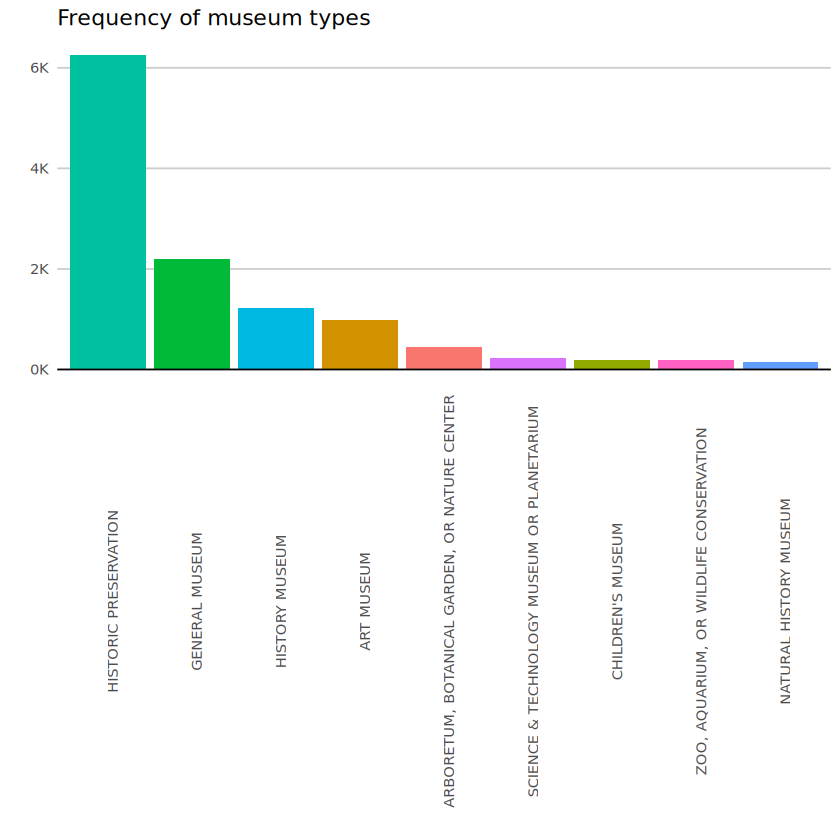

In [221]:
# Create the plot.
museum_type <- 
  ggplot(
    data = museums_df, 
    aes(
      x = fct_infreq(Museum.Type), 
      fill = Museum.Type, 
    )
  ) +
  geom_bar() + 
  geom_hline(yintercept = 0) + 
  labs(
    title = "Frequency of museum types", 
    x = "", 
    y = "", 
  ) +
  scale_y_continuous(
    labels = scales::label_number(scale = 0.001, suffix = "K")
  ) + 
  theme_minimal() + 
  theme(
    axis.text.x = element_text(angle = 90), 
    legend.position = "none", 
    panel.grid.minor = element_blank(), 
    panel.grid.major.x = element_blank(), 
    panel.grid.major.y = element_line(color = "grey80"), 
  )

# Display the plot.
museum_type

<br><input type='checkbox'></input><b>  4.</b>

The plot we just created is hard to read because our categories are long. Add a `scale_x_discrete()` layer to customize our x axis, using the function `scales::wrap_format(8)` to reformat our labels.

`wrap_format()` is a function from the `scales` packages which comes included with `ggplot2`. By setting the value of `wrap_format()` to `8`, we are telling it that the maximum width per line should be no more than `8` characters.

Now we should be able to see which category is most common. Great job! Give yourself a pat on the back.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To apply a function `example_function()` to axis labels on the x axis, we can add a layer like `scale_x_discrete(labels = example_function())`. 

</div>
</details>

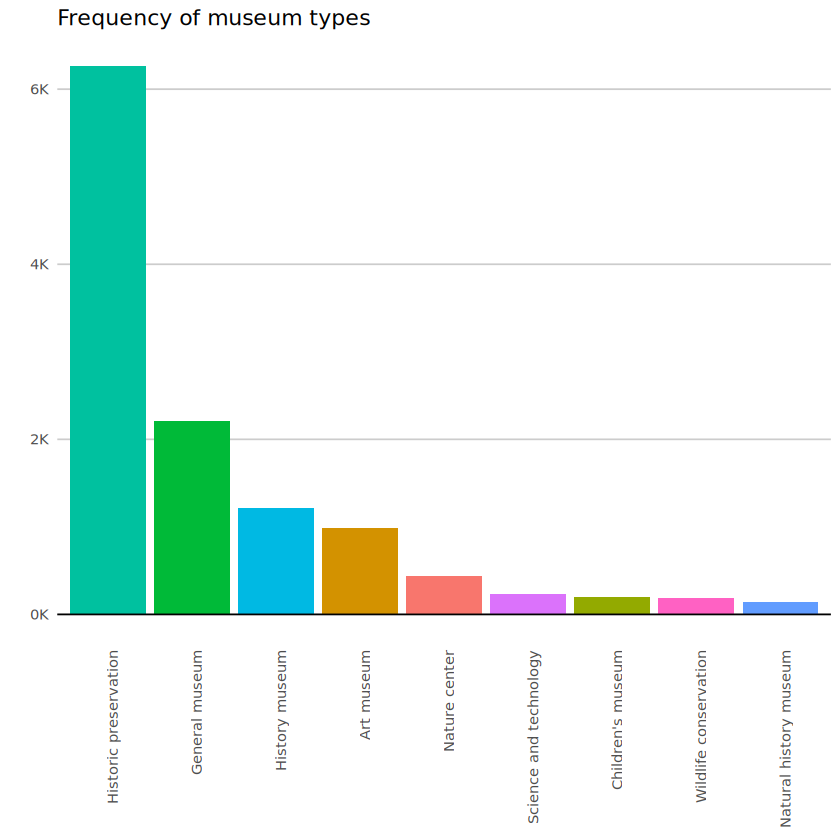

In [ ]:
# Rename the x-axis labels.
museum_type <-museum_type + 
  scale_x_discrete(
    labels = function(x) {
      x <- as.character(x)
      
      # Rename specific long labels.
      x <- recode(
        x,
        "SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM" = "Science and technology",
        "ZOO, AQUARIUM, OR WILDLIFE CONSERVATION" = "Wildlife conservation",
        "ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER" = "Nature center"
      )
      
      # Apply sentence case to all remaining labels.
      stringr::str_to_sentence(x)
    }
  ) + 
  theme(axis.text.x = element_text(hjust = 1))

# Display the plot.
museum_type

<br><input type='checkbox'></input><b>  5.</b>

We’ve included a boolean (`TRUE` or `FALSE`) column in our data frame called `Is.Museum`. The `TRUE` category includes typical museums like art, history, and science museums. The `FALSE` category includes zoos, aquariums, nature preserves, and historic sites, which are included in this data but aren’t what most people think of when they hear the word “museum.”

Create a new bar plot called `museum_class`, mapping `Is.Museum` to the `x` axis. Since “TRUE” and “FALSE” aren’t very descriptive, use `scale_x_discrete()` to rename the `x` axis labels to more easily understood terms – for example, “Museum” vs “Non-Museum”.


<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To relabel existing axis labels on a discrete `x` axis, we can add a layer like:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
scale_x_discrete(
  labels = c(
    "Original Name 1" = "New Name 1", 
    "Original Name 2" = "New Name 2"
  )
)
```

</div>

Note that these labels are case sensitive! Make sure you’re using `"TRUE"` and `"FALSE"` as capitalized in the data.

</div>
</details>

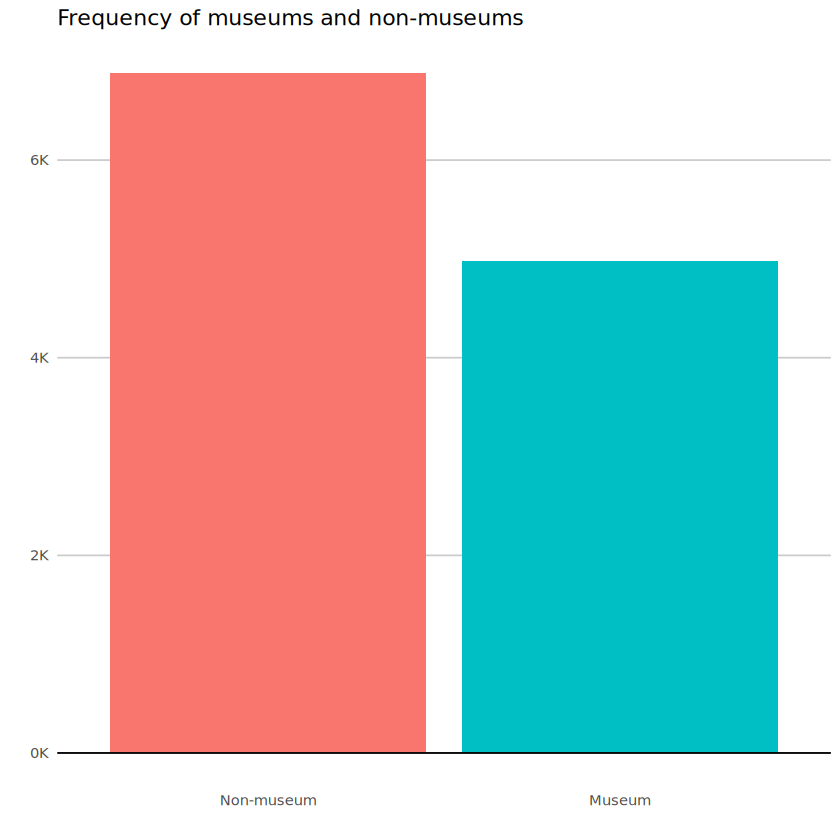

In [196]:
# Create the plot.
museum_class <-
  ggplot(
    data = museums_df, 
    aes(
      x = Is.Museum, 
      fill = Is.Museum, 
    ),
  ) +
  geom_bar() +
  geom_hline(yintercept = 0) + 
  labs(
    title = "Frequency of museums and non-museums",
    y = "", 
    x = "", 
  ) +
  scale_fill_discrete(
    name = "Type of museum", 
    labels = c("Museum", "Non-museum"), 
  ) + 
  scale_x_discrete(
    labels = c(
      "TRUE" = "Museum", 
      "FALSE" = "Non-museum"
    )
  ) + 
  scale_y_continuous(labels = scales::label_number(scale = 0.001, suffix = "K")) + 
  theme_minimal() + 
  theme(
    legend.position = "none", 
    panel.grid.minor = element_blank(), 
    panel.grid.major.x = element_blank(), 
    panel.grid.major.y = element_line(color = "grey80"), 
  )

# Display the plot.
museum_class

<br><input type='checkbox'></input><b>  6.</b>

Instead of looking at the distribution across the entire United States, maybe we’re just interested in a few states. Filter `museums_df` to include a few states you might be interested in, using the `State..Administrative.Location.` column; for example, we can choose `IL`, `CA`, and `NY`. Call this filtered data frame `museums_states`.

After creating `museums_states`, recreate our bar plot showing the distribution of museums vs non-museums and use `facet_grid()` to display each state’s distribution in a separate panel. Call this plot `museum_facet`. How does the distribution of museum vs non-museum vary across the states you chose?


<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To filter a data frame by a logical condition, we can use the `filter()` function from `dplyr`. For example, the following code would filter data frame `df` to include only rows where values in column `Animal` equal `"dog"` or `"cat"`.

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
df_filtered <- df %>%
  filter(Animal == "dog" | Animal == "cat")
```

</div>

To add facets to a plot, we can add a `facet_grid()` layer. If we want to show values of a variable `example_var` as columns, we would write `facet_grid(cols = vars(example_var))`. To represent values of this variable in rows, we can replace `cols` argument with the `rows`  argument in the above code snippet. 

</div>
</details>

In [197]:
# Create a new DataFrame of museums in three specific states.
museums_states <- museums_df %>%
 filter(
   State..Administrative.Location. == "LA" |
   State..Administrative.Location. == "CA" |
   State..Administrative.Location. == "NY" 
  ) %>%
  mutate(
    State..Administrative.Location. = factor(
      State..Administrative.Location., 
      levels = c( "NY", "CA", "LA")
    )
  )

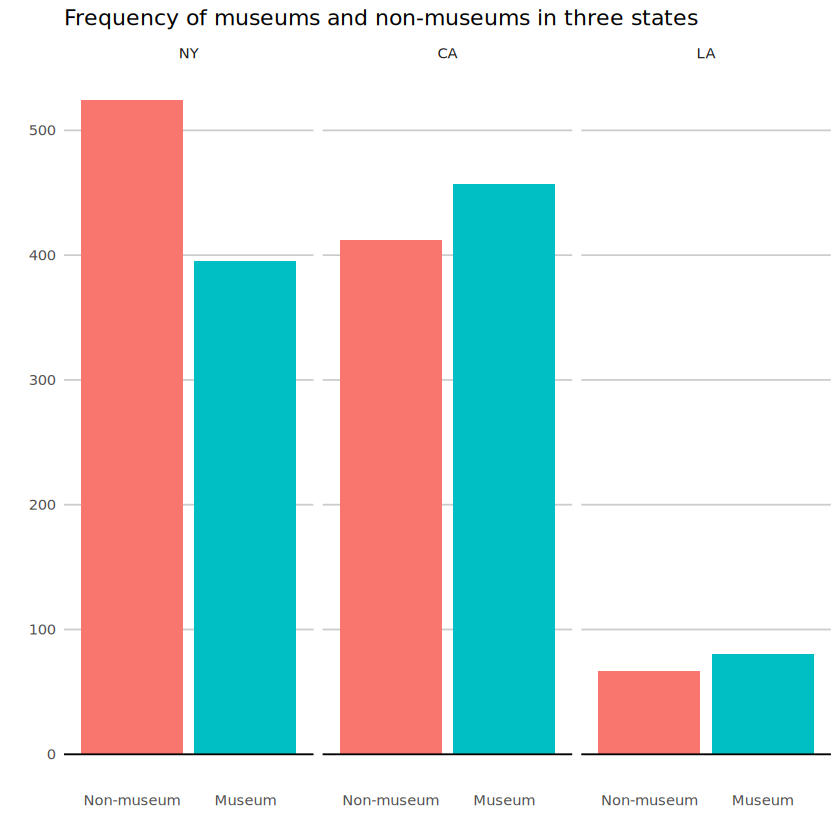

In [198]:

# Create the plot.
museum_facet <- ggplot(
  data = museums_states, 
  aes(
    x = Is.Museum, 
    fill = Is.Museum, 
    )
  ) + 
  geom_bar() + 
  geom_hline(yintercept = 0) + 
  labs(
    title = "Frequency of museums and non-museums in three states", 
    y = "", 
    x = "", 
  ) +
  scale_x_discrete(
    labels = c(
      "TRUE" = "Museum", 
      "FALSE" = "Non-museum"
    )
  ) + 
  scale_fill_discrete(
    name = "", 
    labels = c("Museum", "Non-museum"), 
  ) +
  facet_grid(cols = vars(State..Administrative.Location.)) + 
  theme_minimal() + 
  theme(
    legend.position = "none", 
    panel.grid.minor = element_blank(), 
    panel.grid.major.x = element_blank(), 
    panel.grid.major.y = element_line(color = "grey80"), 
  )

# Display the plot.
museum_facet

<br><input type='checkbox'></input><b>  7.</b>

Our data also contains information on each museum’s region, representing groups of states. Create a stacked bar plot using `museums_df` showing the count of museums by region (`Region.Code..AAM.`), mapping `Is.Museum` to the `fill` aesthetic. Convert `Region.Code..AAM.` to a factor (e.g. `factor(Region.Code..AAM.)`) so `ggplot2` plots its levels as discrete rather than continuous values. Call this plot `museum_stacked`.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To create a stacked bar plot, add a `fill` aesthetic mapping providing the variable whose values we want to show as bar segments. For example, if we had a data frame `df` and we wanted to plot `Species` on the `x` axis, show counts on the `y` axis, and use ` Color` as our fill variable, we would write:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
ggplot(df, aes(x = Species, fill = Color)) + geom_bar()
```

</div>
</div>
</details>

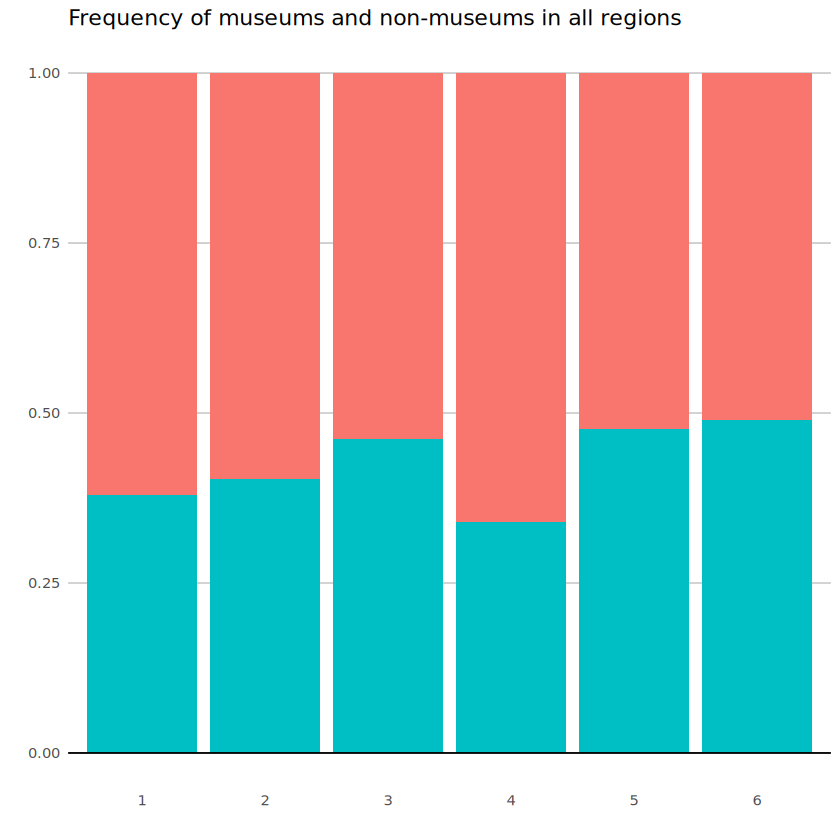

In [199]:
# Create the plot.
museum_stacked <- ggplot(
  data = museums_df,
  aes(
    x = factor(Region.Code..AAM.), 
    fill = Is.Museum
      )
    ) + 
  geom_bar(position="fill") + 
  geom_hline(yintercept = 0) +
  labs(
    title = "Frequency of museums and non-museums in all regions", 
    y = "", 
    x = "", 
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(color = "grey80")
  )

# Display the plot.
museum_stacked

<br><input type='checkbox'></input><b>  8.</b>

Our plot is hard to read – right now, we don’t know what the region numbers correspond to. Use `scale_x_discrete()` to rename the numeric labels to text according to the following table.

| Code | Region            |
|------|------------------_|
| 1    | New England       |
| 2    | Mid-Atlantic      |
| 3    | Southeastern      |
| 4    | Midwest           |
| 5    | Mountain Plains   |
| 6    | Western           |

Similarly, add a `scale_fill_discrete()` layer to relabel the “TRUE” and “FALSE” labels in our legend to “Museum” and “Non-Museum”.

Based on the plot we created, which region has the most museums?

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To relabel existing axis labels on a discrete `x` axis, we can add a layer like:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
scale_x_discrete(
  labels = c(
    "Original Name 1" = "New Name 1", 
    "Original Name 2" = "New Name 2"
  )
)
```

</div>

We can relabel legend labels for our `fill` variable the same way using `scale_fill_discrete()`.

</div>
</div>
</details>

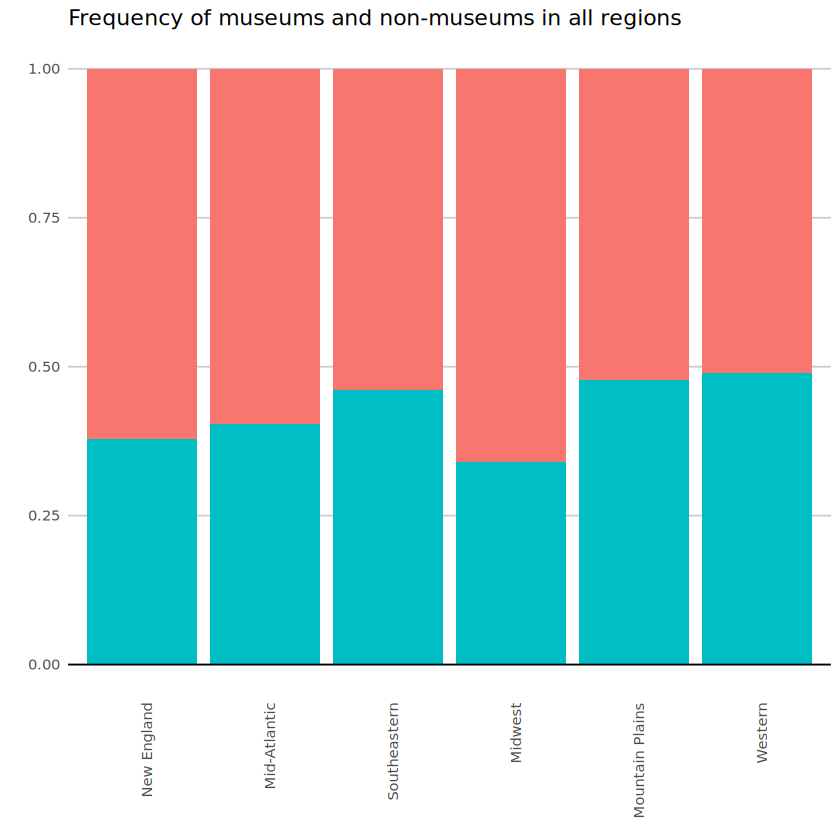

In [200]:
# Format the axes labels.
museum_stacked <-museum_stacked +
  scale_fill_discrete(
    name = "", 
    labels = c("TRUE" = "Museum", "FALSE" = "Non-museum")
  ) +
  scale_x_discrete(
    labels = c(
      "1" = "New England", 
      "2" = "Mid-Atlantic", 
      "3" = "Southeastern", 
      "4" = "Midwest",
      "5" = "Mountain Plains",
      "6" = "Western"
    )
  ) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

# Display the plot.
museum_stacked

<br><input type='checkbox'></input><b>  9.</b>

Rather than seeing counts, perhaps we’re more interested in the percentage of museums vs non-museums by region. Transform the plot we just created to a stacked bar plot showing values out of 100% by passing `position = "fill"` to our `geom_bar()` layer. Apply the `scales::percent_format()` function to transform our `y` axis labels into percentage values.

How does the distribution of museum types vary by region?

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To apply a function `example_function()` to continuous `y` axis labels, provide the function to the `labels` argument of the layer like this:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
scale_y_continuous(labels = example_function()) 
```

</div>
</div>
</details>

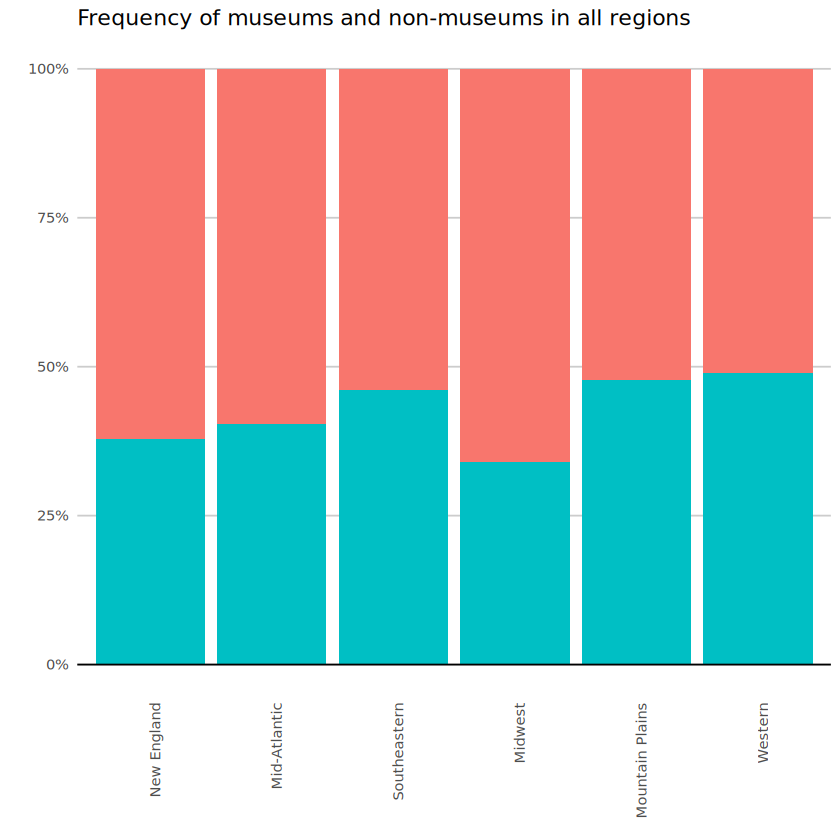

In [201]:
# Create teh plot.
museum_stacked <- ggplot(
  data = museums_df,
  aes(
    x = factor(Region.Code..AAM.), 
    fill = Is.Museum
      )
    ) + 
  geom_bar(position="fill") +
  geom_hline(yintercept = 0) +
  labs(
    title = "Frequency of museums and non-museums in all regions", 
    y = "", 
    x = "", 
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(color = "grey80")
  ) + 
  scale_fill_discrete(
    name = "", 
    labels = c("TRUE" = "Museum", "FALSE" = "Non-museum")
  ) +
  scale_x_discrete(
    labels = c(
      "1" = "New England", 
      "2" = "Mid-Atlantic", 
      "3" = "Southeastern", 
      "4" = "Midwest",
      "5" = "Mountain Plains",
      "6" = "Western"
    )
  ) + 
  scale_y_continuous(labels = scales::percent_format()) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

# Display the plot.
museum_stacked

<br><input type='checkbox'></input><b>  10.</b>

Our graph looks pretty good! However, our axes titles are a little non-descript. Using the `labs()` layer, let’s title this plot “Museum Types by Region”, relabel the x axis title as “Region”, relabel the `y` axis title as “Percentage of Total”, and relabel the `fill` legend title as “Type”.

Now, someone can take a look at this plot and immediately understand what is being described. There were a lot of steps here, but now our plot is clear and professional. Give yourself a pat on the back, and feel free to take a 10 minute coffee break before the next section! 

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To add and adjust titles on our plot, include a `labs()` layer e.g.:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
labs(title = "Title of Graph", x = "X Axis Title", y = "Y Axis Title", fill = "Legend Title")
```

</div>
</div>
</details>

## <h2 style='font-size: 1.5em; font-weight: bold;'>Explore institutions by revenue</h2>

<br><input type='checkbox'></input><b>  11.</b>

For the next few tasks, we’ll switch to looking at how much money each institution brought in and how that varies across geographies. Because we only have revenue data at the parent organization level, we’ll want to first filter our dataset to omit any duplicates. Next, we’ll create a few data frames from our starting data to look at different groups of museums by how much money they bring in.

Create a new data frame called `museums_revenue_df` that retains only unique values of `Legal.Name` in `museums_df`. Additionally, filter this data frame to include only entities with `Annual.Revenue greater` than 0.

Create a second data frame from `museums_revenue_df` (the first data frame we created in this task) called `museums_small_df` that retains only museums with `Annual.Revenue` less than $1,000,000.

Create a third data frame from `museums_revenue_df` (the first data frame we created in this task) called `museums_large_df` that retains only museums with `Annual.Revenue` greater than $1,000,000,000.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

We can retain only unique rows of a data frame using the `dplyr` function `distinct()`, specifying which variable(s) we want to retain distinct values of. Make sure to include the argument `.keep_all = TRUE` so that all columns are retained, rather than just the one column we want to check uniqueness for. For example, the following code will retain only rows with unique values of `Species` in the data frame `df`, keeping all columns.
  
<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
df <- df %>%
  distinct(Species, .keep_all = TRUE)
```

</div>
</div>
</details>

In [202]:
# Create a new DataFrame of museums with revenue.
museums_revenue_df <- 
  museums_df %>% 
  distinct(
    Legal.Name, 
    .keep_all = TRUE
    ) %>% 
  filter(Annual.Revenue > 0)

# Create a new DataFrame of museums with small revenue.
museums_small_df <- 
  museums_revenue_df %>% 
  filter(Annual.Revenue < 1000000)

# Create a new DataFrame of museums with large revenue.
museums_large_df <- 
  museums_revenue_df %>% 
  filter(Annual.Revenue > 1000000000)

<br><input type='checkbox'></input><b>  12.</b>

Let’s start by visualizing the distribution of annual revenue for our small museums dataset. Create a histogram called `revenue_histogram` using `museums_small_df` with `Annual.Revenue` mapped to the `x` axis. Experiment with different `binwidth` values to see what works best for our data, considering that our `x` axis variable ranges from 0 to $1,000,000.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

Use the `geom_histogram()` layer to create a histogram. The `binwidth` argument controls the size of ranges that get counted together for the provided variable.

</div>
</details>

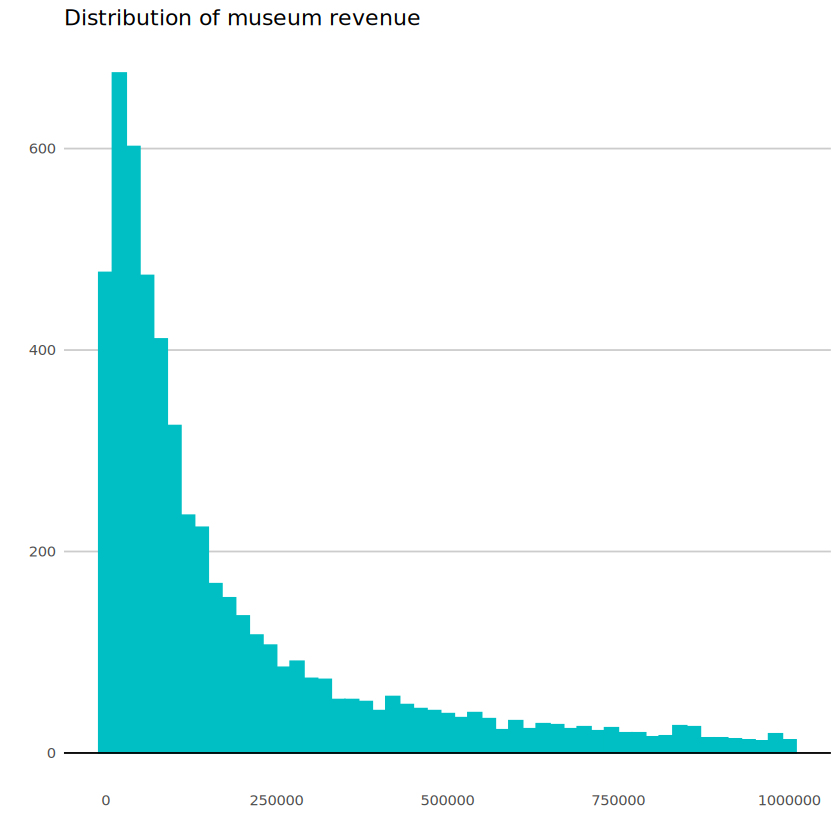

In [203]:
# Create the plot.
revenue_histogram <- 
  ggplot(
    data = museums_small_df, 
    aes(x = Annual.Revenue), 
   ) + 
  labs(
    title = "Distribution of museum revenue", 
    x = "", 
    y = "", 
  ) +
  geom_histogram(
    binwidth = 1000000/50, 
    color = "#00BFC4", 
    fill = "#00BFC4", 
  ) +
  geom_hline(yintercept = 0) + 
  theme_minimal() + 
  theme(
    legend.position = "none", 
    panel.grid.minor = element_blank(), 
    panel.grid.major.x = element_blank(), 
    panel.grid.major.y = element_line(color = "grey80"), 
  )  

# Display the plot.
revenue_histogram

<br><input type='checkbox'></input><b>  13.</b>

Our `x` axis is a little hard to read. Let’s make it more clear! Add a `scale_x_continuous()` layer applying the function `scales::dollar_format()` to our `x` axis labels. `dollar_format()` is a function from the `scales` library included in `ggplot2` that adds dollar signs and commas to monetary data.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To apply a function `example_function()` to continuous `x` axis `labels`, provide the function to the labels argument of the layer like this:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
scale_x_continuous(labels = example_function()) 
```

</div>
</div>
</details>

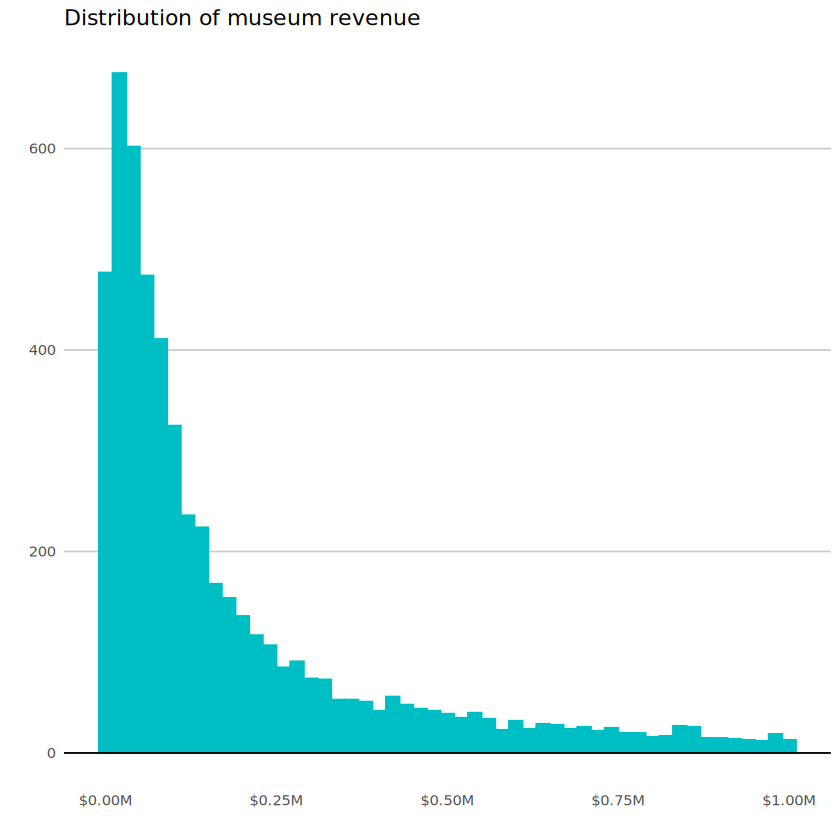

In [204]:
# Format the axes labels.
revenue_histogram <- revenue_histogram + 
  scale_y_continuous(labels = scales::comma) + 
  scale_x_continuous(
    labels = scales::dollar_format(
      prefix = "$", 
      big.mark = ",", 
      scale = 1e-6, 
      suffix = "M"
    )
  )

# Display the plot.
revenue_histogram

<br><input type='checkbox'></input><b>  14.</b>

Now, let’s look at the variation in revenue for large museums by region. Create a boxplot called `revenue_boxplot` using `museums_large_df`, mapping `Region.Code..AAM.` to the x axis and `Annual.Revenue` to the `y` axis. Remember to convert `Region.Code..AAM.` to a factor (e.g. `factor(Region.Code..AAM.)`) so `ggplot2` plots its levels as discrete rather than continuous values. Use `scale_x_discrete()` to rename the numeric region codes to their text equivalents.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To relabel existing axis labels on a discrete `x` axis, we can add a layer like:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
scale_x_discrete(
  labels = c(
    "Original Name 1" = "New Name 1", 
    "Original Name 2" = "New Name 2"
  )
)
```

</div>
</div>
</div>
</details>

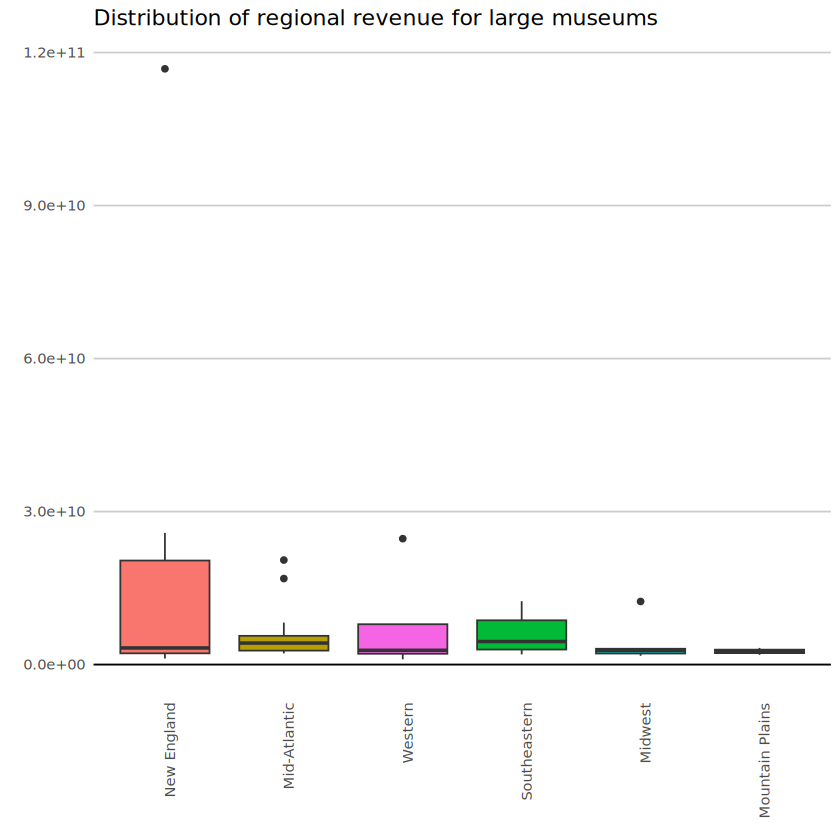

In [205]:
# Create the plot.
revenue_boxplot <-
  ggplot(
    data = museums_large_df, 
    aes(
      x = fct_reorder(factor(Region.Code..AAM.), Annual.Revenue, .fun=sum, .desc=TRUE), 
      y = Annual.Revenue, 
      fill = factor(Region.Code..AAM.)
    )
  ) + 
  geom_boxplot() + 
  geom_hline(yintercept = 0) + 
  labs(
    title = "Distribution of regional revenue for large museums",
    x = "",
    y = "", 
  ) + 
  scale_fill_discrete(
    name = "Region", 
    labels = c(
      "1" = "New England", 
      "2" = "Mid-Atlantic", 
      "3" = "Southeastern", 
      "4" = "Midwest",
      "5" = "Mountain Plains",
      "6" = "Western"
    )
  ) + 
  scale_x_discrete(
    labels = c(
      "1" = "New England", 
      "2" = "Mid-Atlantic", 
      "3" = "Southeastern", 
      "4" = "Midwest",
      "5" = "Mountain Plains",
      "6" = "Western"
    )
  ) +
  theme_minimal() + 
  theme(
    axis.text.x = element_text(
      angle = 90, 
      hjust = 1, 
    ), 
    legend.position = "none", 
    panel.grid.minor = element_blank(), 
    panel.grid.major.x = element_blank(), 
    panel.grid.major.y = element_line(color = "grey80"), 
  )

# Display the plot.
revenue_boxplot

<br><input type='checkbox'></input><b>  15.</b>

The plot we just created is a little hard to read, since there’s one outlier so far above all the other data points. This one museum made a lot of money in 2013! Let’s zoom in so we can see the rest of our boxes more clearly. Add a `coord_cartesian()` layer setting ylim to `c(1e9, 3e10)`. This tells our plot to zoom in on the `y` axis range between $1,000,000,000 and $30,000,000,000. How do the median, 75th, and 25th quantiles vary by region?

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To zoom in on only values between 1 and 10 on a `y` axis, we would include the following layer:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
coord_cartesian(ylim = c(1, 10))
```

</div>
</div>
</div>
</details>

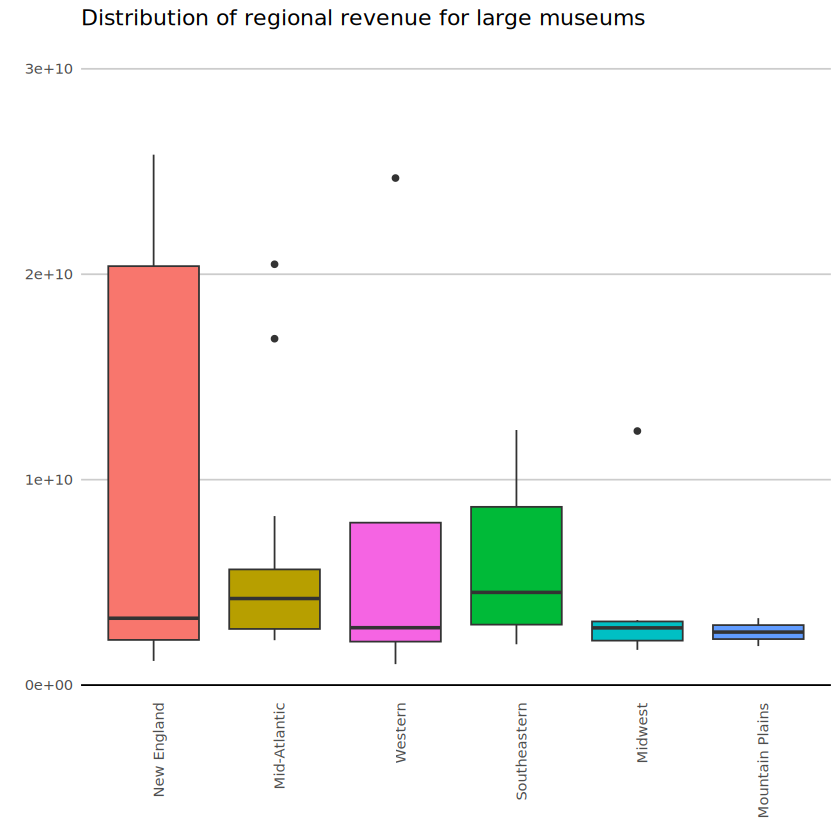

In [206]:
# Limit the y-axis.
revenue_boxplot <- revenue_boxplot + 
  coord_cartesian(ylim = c(1e9, 3e10))

# Display the plot.
revenue_boxplot

<br><input type='checkbox'></input><b>  16.</b>

Though we can see the distribution by region more clearly now, our `y` axis label is hard to understand. Let’s reformat our `y` axis as billions of dollars. The function defined below will convert values like $1,000,000,000 to $1B, which is much easier to read. Add a `scale_y_continuous()` layer to map our `y` axis labels using this function.

```python
function(x) paste0("$", x/1e9, "B")


We’ve made our box plot much clearer to read. Great work! If you’re feeling tired, you can always take a quick break – you’ve earned it!

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

We can define a function to transform our axis labels using the `labels` function. For example, the following layer will round all labels on a continuous `y` axis.

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
scale_y_continuous(labels = function(x) round(x))
```

</div>
</div>
</div>
</details>

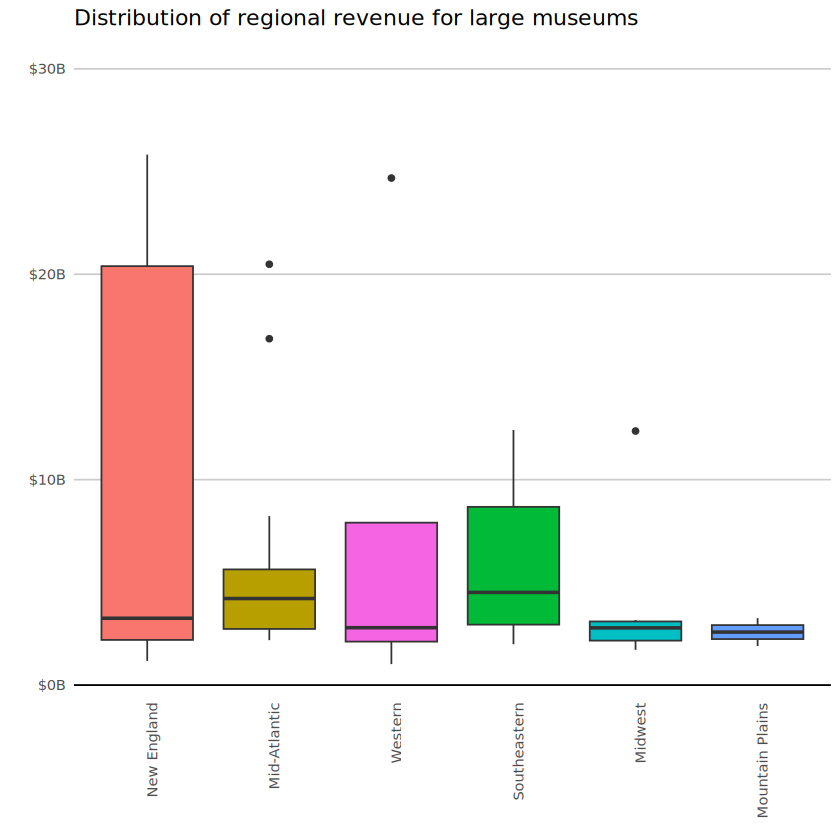

In [207]:
# Format the y-axis labels as billions of dollars.
revenue_boxplot <- revenue_boxplot + 
  scale_y_continuous(
    labels = scales::dollar_format(
      prefix = "$", 
      big.mark = ",", 
      scale = 1e-9, 
      suffix = "B",
      accuracy = 1, 
    )
  )

# Display the plot.
revenue_boxplot

<br><input type='checkbox'></input><b>  17.</b>

Now, let’s take a look at revenue across all museums in our dataset. Using `museums_revenue_df`, create a bar plot called `revenue_barplot` mapping `Region.Code..AAM.` to the `x` axis and `Annual.Revenue` to the `y` axis. Remember to transform `Region.Code..AAM.` to a factor (`factor(Region.Code..AAM.)`) so it shows up as discrete values.

Use `stat = "summary"` and `fun = "mean"` to calculate and display the mean revenue by region. Apply the appropriate `x` and `y` axis label transformations to make our labels more clear. Which region has the highest and lowest mean revenues?

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To automatically calculate and display mean values on a bar plot, we can use the following arguments in our `geom_bar()` layer:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
geom_bar(stat = "summary", fun = "mean")
```

</div>
</div>
</div>
</details>

In [208]:
# Calculate the mean annual revenue for each region.
region_order <- museums_revenue_df %>%
  group_by(Region.Code..AAM.) %>%
  summarize(Mean.Revenue = mean(Annual.Revenue)) %>%
  arrange(desc(Mean.Revenue)) %>% # order the regions by mean revenue.
  pull(Region.Code..AAM.)

# Reorder on mean annual revenue.
museums_revenue_df <- museums_revenue_df %>%
  mutate(Region.Code..AAM. = factor(
    Region.Code..AAM., 
    levels = region_order
  ))

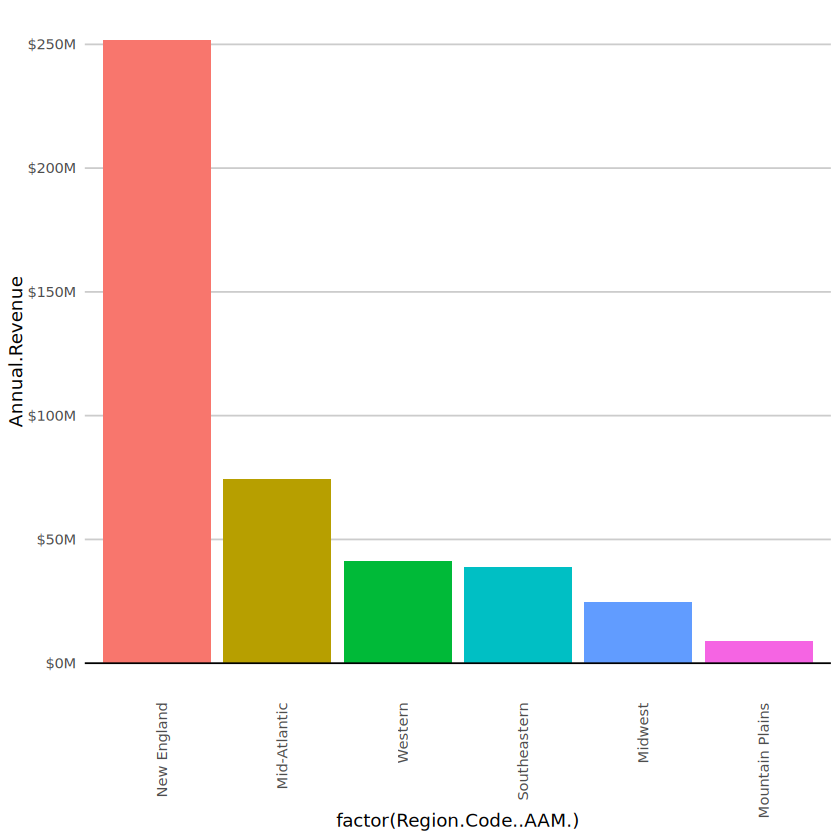

In [209]:
# Create the plot.
revenue_barplot <-
  ggplot(
    data = museums_revenue_df,
    aes(
      x = factor(Region.Code..AAM.), 
      y = Annual.Revenue,
      fill = factor(Region.Code..AAM.)
    )
  ) +
  geom_bar(
    stat = "summary", 
    fun = "mean"
  ) +
  geom_hline(yintercept = 0) + 
  scale_x_discrete(
    labels = c(
      "1" = "New England", 
      "2" = "Mid-Atlantic", 
      "3" = "Southeastern", 
      "4" = "Midwest",
      "5" = "Mountain Plains",
      "6" = "Western"
      )
    ) +
  scale_y_continuous(
    labels = scales::dollar_format(
      prefix = "$", 
      big.mark = ",", 
      scale = 1e-6, 
      suffix = "M",
      accuracy = 1, 
    )
  ) + 
  theme_minimal() + 
  theme(
    axis.text.x = element_text(
      angle = 90, 
      hjust = 1, 
    ), 
    legend.position = "none", 
    panel.grid.minor = element_blank(), 
    panel.grid.major.x = element_blank(), 
    panel.grid.major.y = element_line(color = "grey80"), 
  )

# Display the plot.
revenue_barplot

<br><input type='checkbox'></input><b>  18.</b>

Once again, use the `labs` layer to make our plot more clear. Title the plot “Mean Annual Revenue by Region”, relabel the `y` axis title to “Mean Annual Revenue”, and relabel the `x` axis title to “Region”.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To add and adjust titles on our plot, include a `labs()` layer e.g.:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
labs(title = "Title of Graph", x = "X Axis Title", y = "Y Axis Title")
```

</div>
</div>
</div>
</details>

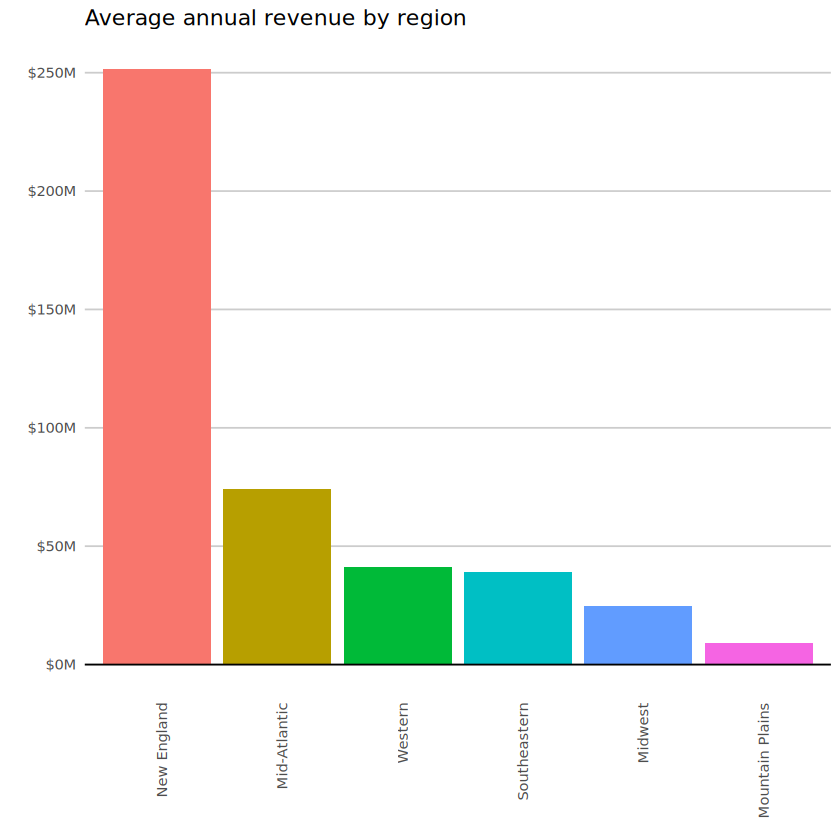

In [210]:
# Add labels to the plot.
revenue_barplot <-revenue_barplot + 
  labs(
    title = "Average annual revenue by region",
    x = "", 
    y = "", 
  )

# Display the plot.
revenue_barplot 

<br><input type='checkbox'></input><b>  19.</b>

Finally, let’s add some error bars to our means. We’ll need to calculate our standard errors before creating our plot. You can do so using the following code:

```python
museums_error_df <- museums_revenue_df %>%
  group_by(Region.Code..AAM.) %>%
  summarize(
    Mean.Revenue = mean(Annual.Revenue), 
    Mean.SE = std.error(Annual.Revenue)) %>%
  mutate(
    SE.Min = Mean.Revenue - Mean.SE, 
    SE.Max = Mean.Revenue + Mean.SE)


Add error bars to our mean revenue by geography bar plot using the `geom_errorbar()` layer. Call this new plot `revenue_errorbar`. Our new `y` variable is our calculated `Mean.Revenue` column. Make sure to change the `stat` being used, since we’re now displaying our calculated means as is rather than calculating them as we create the plot. Which regions have more or less variability around their mean revenues?

Congratulations – you’ve completed this project! Awesome work today.

<details>
<summary style='
  background-color: #FFF2B3;
  border: 1px solid #E2D7A2;
  color: black;
  display: flex;
  font-weight: bold;
  padding: 8px 16px; 
  width: 95%;
'>
Stuck? Get a hint
</summary>
<div style='
  background-color: #FFFAE5;
  border: 1px solid #E2D7A2;
  color: #000000;
  padding: 8px 16px; 
  width: 95%;
'>

To add standard errors where the lower and upper bounds are represented by variables `SE.Min` and `SE.Max`, we can add the following layer:

<div style='
  background-color: #000000; 
  padding: 16px 16px;
  width: 97%;
'>

```python
geom_errorbar(
  aes(
    ymin = SE.Min, 
    ymax = SE.Max), 
  width = 0.2)
```

</div>

To display values as is, rather than displaying counts, we can use `geom_col()` or `geom_bar(stat = "identity")`.

</div>
</div>
</details>

In [ ]:
# Create a DataFrame with mean and standard error of annual revenue for each region.
museums_error_df <- 
  museums_revenue_df %>%
  group_by(Region.Code..AAM.) %>%
  summarize(
    Mean.Revenue = mean(Annual.Revenue), 
    Mean.SE = std.error(Annual.Revenue)
    ) %>%
  mutate(
    SE.Min = Mean.Revenue - Mean.SE, 
    SE.Max = Mean.Revenue + Mean.SE
    )

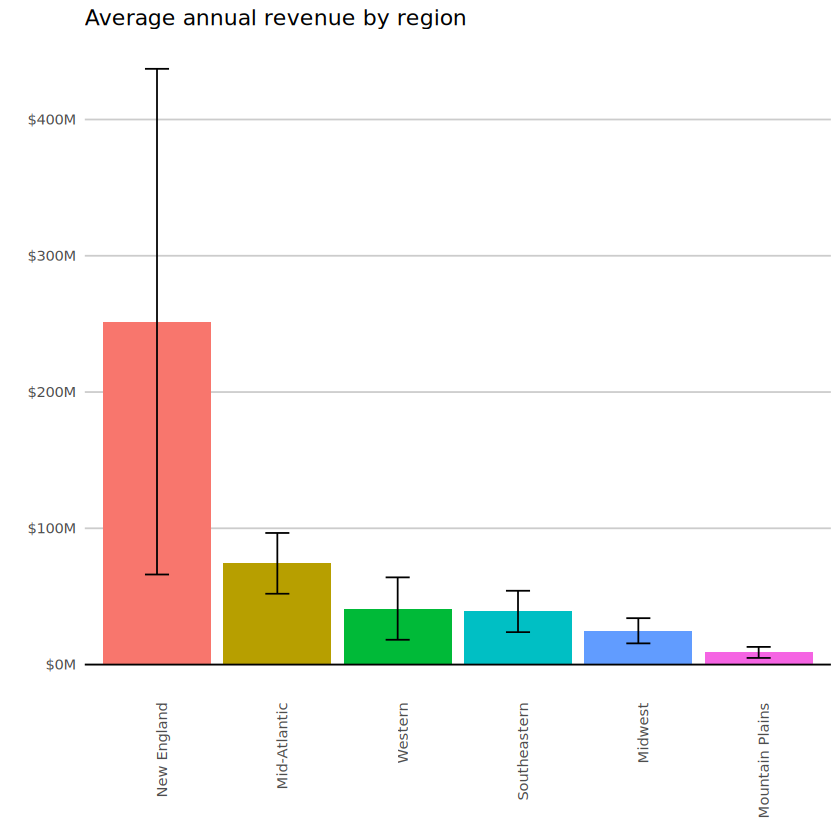

In [212]:
# Create the plot.
revenue_errorbar <- 
  ggplot(
    data = museums_error_df,
    aes(
      x = factor(Region.Code..AAM.), 
      y = Mean.Revenue,
      fill = factor(Region.Code..AAM.)
    )
  ) + 
  geom_bar(stat = "identity") +
  geom_errorbar(
    aes(
      ymin = SE.Min, 
      ymax = SE.Max
    ), 
    width = 0.2
  ) + 
  geom_hline(yintercept = 0) +
  labs(
    title = "Average annual revenue by region",
    x = "", 
    y = ""
  ) + 
  theme_minimal() + 
  theme(
    axis.text.x = element_text(
      angle = 90, 
      hjust = 1, 
    ), 
    legend.position = "none", 
    panel.grid.minor = element_blank(), 
    panel.grid.major.x = element_blank(), 
    panel.grid.major.y = element_line(color = "grey80"), 
  ) + 
  scale_x_discrete(
    labels = c(
      "1" = "New England", 
      "2" = "Mid-Atlantic", 
      "3" = "Southeastern", 
      "4" = "Midwest",
      "5" = "Mountain Plains",
      "6" = "Western"
      )
    ) +
  scale_y_continuous(labels = function(x) paste0("$", x/1e6, "M"))

# Display the plot.
revenue_errorbar